In [19]:
# Import Libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

In [ ]:
# Association between two random variables

In [2]:
# Load housing dataset for analysis
# index_col=0 → use first column as index (instead of default numeric index)

housing = pd.read_csv('data/housing.csv', index_col=0)

# display first 5 rows to inspect structure
housing.head()

,LSTAT,INDUS,NOX,RM,MEDV
0,4.98,2.31,0.538,6.575,24.0
1,9.14,7.07,0.469,6.421,21.6
2,4.03,7.07,0.469,7.185,34.7
3,2.94,2.18,0.458,6.998,33.4
4,5.33,2.18,0.458,7.147,36.2


In [3]:
# Compute covariance matrix for housing dataset
# covariance shows how two variables move together

housing.cov()

,LSTAT,INDUS,NOX,RM,MEDV
LSTAT,50.994760,29.580270,0.488946,-3.079741,-48.447538
INDUS,29.580270,47.064442,0.607074,-1.887957,-30.520823
NOX,0.488946,0.607074,0.013428,-0.024603,-0.455412
RM,-3.079741,-1.887957,-0.024603,0.493671,4.493446
MEDV,-48.447538,-30.520823,-0.455412,4.493446,84.586724


In [4]:
# Compute correlation matrix for housing dataset
# correlation measures strength and direction of linear relationship (scaled -1 to 1)

housing.corr()


,LSTAT,INDUS,NOX,RM,MEDV
LSTAT,1.000000,0.603800,0.590879,-0.613808,-0.737663
INDUS,0.603800,1.000000,0.763651,-0.391676,-0.483725
NOX,0.590879,0.763651,1.000000,-0.302188,-0.427321
RM,-0.613808,-0.391676,-0.302188,1.000000,0.695360
MEDV,-0.737663,-0.483725,-0.427321,0.695360,1.000000


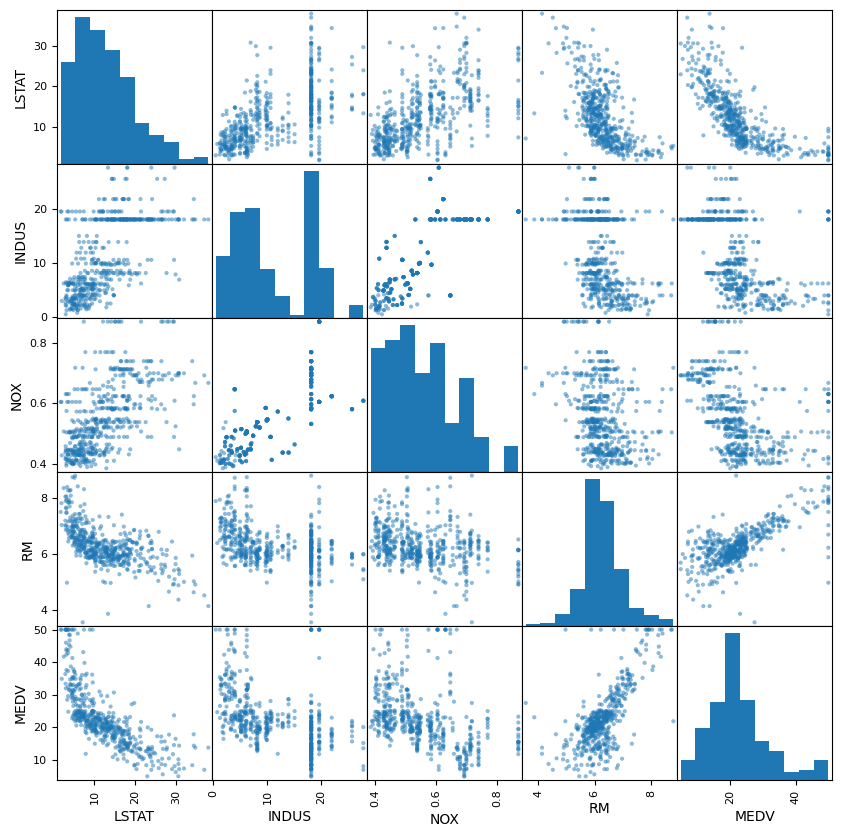

In [ ]:
# Plot scatter matrix for housing dataset
from pandas.plotting import scatter_matrix
sm = scatter_matrix(housing, figsize=(10, 10))

In [ ]:
# Let's do an analysis by yourself!

# Observe the association between LSTAT and MEDV:

<Axes: xlabel='LSTAT', ylabel='MEDV'>

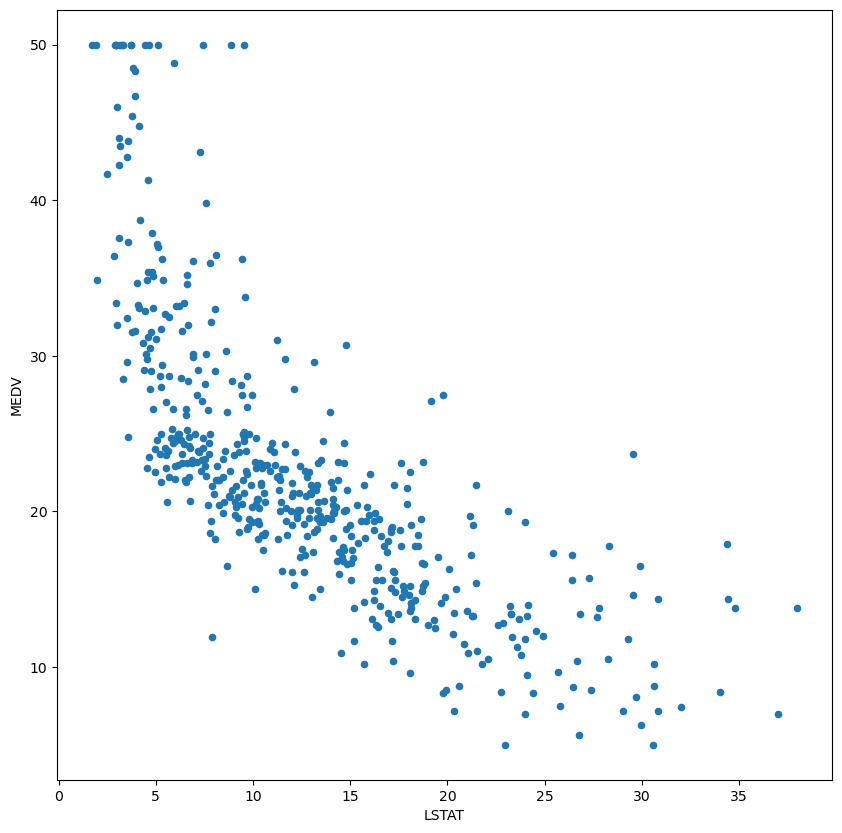

In [6]:
# Scatter plot: MEDV vs LSTAT

housing.plot(kind='scatter', x='LSTAT', y='MEDV', figsize=(10, 10))

In [9]:
# Load housing dataset

# index_col='Unnamed: 0' → use first unnamed column as index
housing = pd.read_csv('data/housing.csv', index_col='Unnamed: 0')

# Show first rows
housing.head()

,LSTAT,INDUS,NOX,RM,MEDV
0,4.98,2.31,0.538,6.575,24.0
1,9.14,7.07,0.469,6.421,21.6
2,4.03,7.07,0.469,7.185,34.7
3,2.94,2.18,0.458,6.998,33.4
4,5.33,2.18,0.458,7.147,36.2


In [11]:
# Fit simple linear regression model: MEDV ~ LSTAT
# statsmodels ordinary least squares (OLS)

model = smf.ols(formula='MEDV~LSTAT', data=housing).fit()


# extract regression coefficients
# b0_ols: intercept
# b1_ols: slope
b0_ols = model.params['Intercept']
b1_ols = model.params['LSTAT']


# predicted values from regression line
# BestResponse = fitted MEDV values based on LSTAT
housing['BestResponse'] = b0_ols + b1_ols * housing['LSTAT']

In [ ]:
# Assumptions behind linear regression model
# 1. Linearity - Linearity refers to a relationship between two variables that can be described using a straight line.
# 2. independence
# 3. Normality
# 4. Equal Variance

<Axes: xlabel='LSTAT', ylabel='MEDV'>

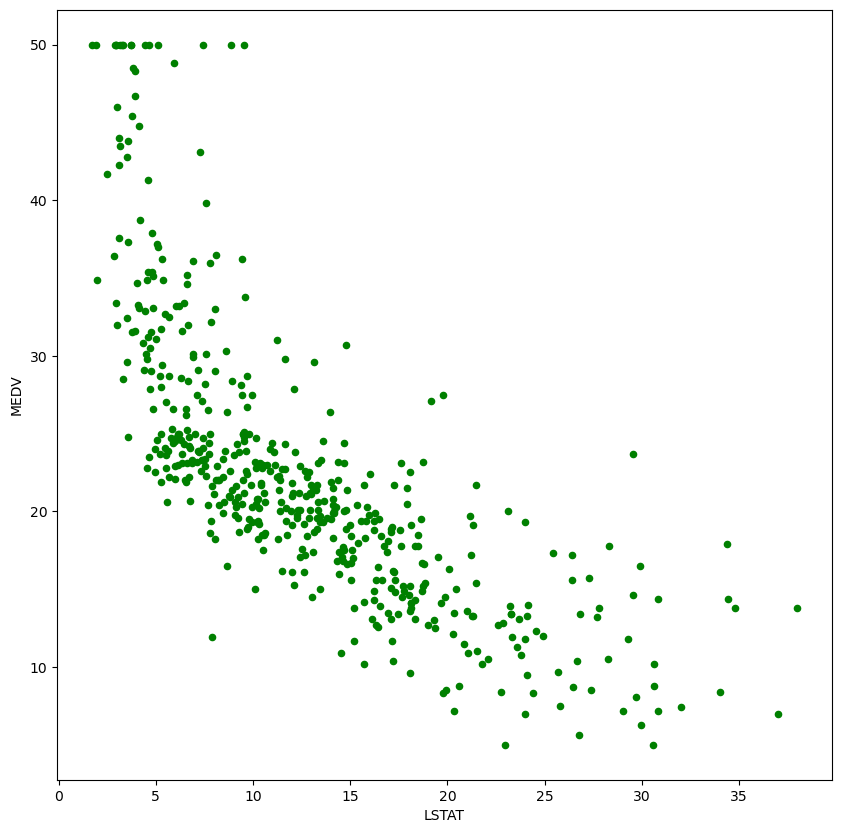

In [ ]:
# Linearity
# Scatter plot to inspect relationship between variables
# x-axis: LSTAT (lower status %)
# y-axis: MEDV (house price)

housing.plot(kind='scatter', x='LSTAT', y='MEDV', figsize=(10, 10), color='g')

In [13]:
# Independence
# Compute residuals (errors)
# error = actual value - predicted value

housing['error'] = housing['MEDV'] - housing['BestResponse']

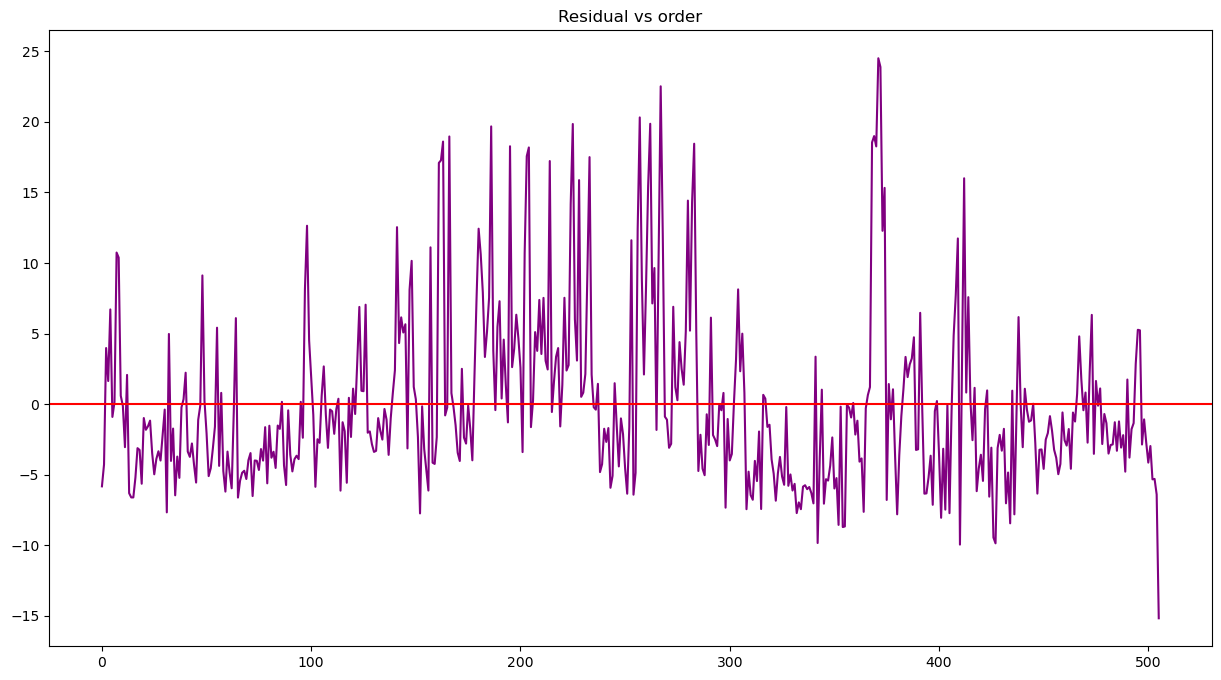

In [14]:
# Create a figure for plotting residuals
plt.figure(figsize=(15, 8))

# Title of the plot
plt.title('Residual vs order')

# Plot residuals over observation order
# x-axis: index (order of data)
# y-axis: error (residuals)
plt.plot(housing.index, housing['error'], color='purple')

# Add horizontal reference line at 0
# helps to see positive vs negative errors
plt.axhline(y=0, color='red')

# Display plot
plt.show()

In [15]:
# Model summary with statistical diagnostics
# includes Durbin-Watson test for autocorrelation in residuals

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   MEDV   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Thu, 11 Jun 2026   Prob (F-statistic):           5.08e-88
Time:                        12:50:48   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     34.5538      0.563     61.415      0.000      33.448      35.659
LSTAT         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

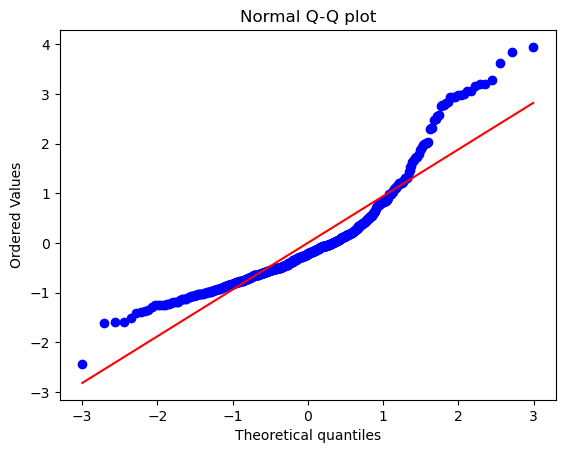

In [16]:
# Normality
# Import statistical functions
import scipy.stats as stats

# Standardize residuals (z-scores)
# z = (error - mean) / standard deviation
z = (housing['error'] - housing['error'].mean()) / housing['error'].std(ddof=1)

# Q-Q plot to check normality of residuals
# compares sample quantiles vs theoretical normal quantiles
stats.probplot(z, dist='norm', plot=plt)

# Plot title
plt.title('Normal Q-Q plot')

# Display plot
plt.show()

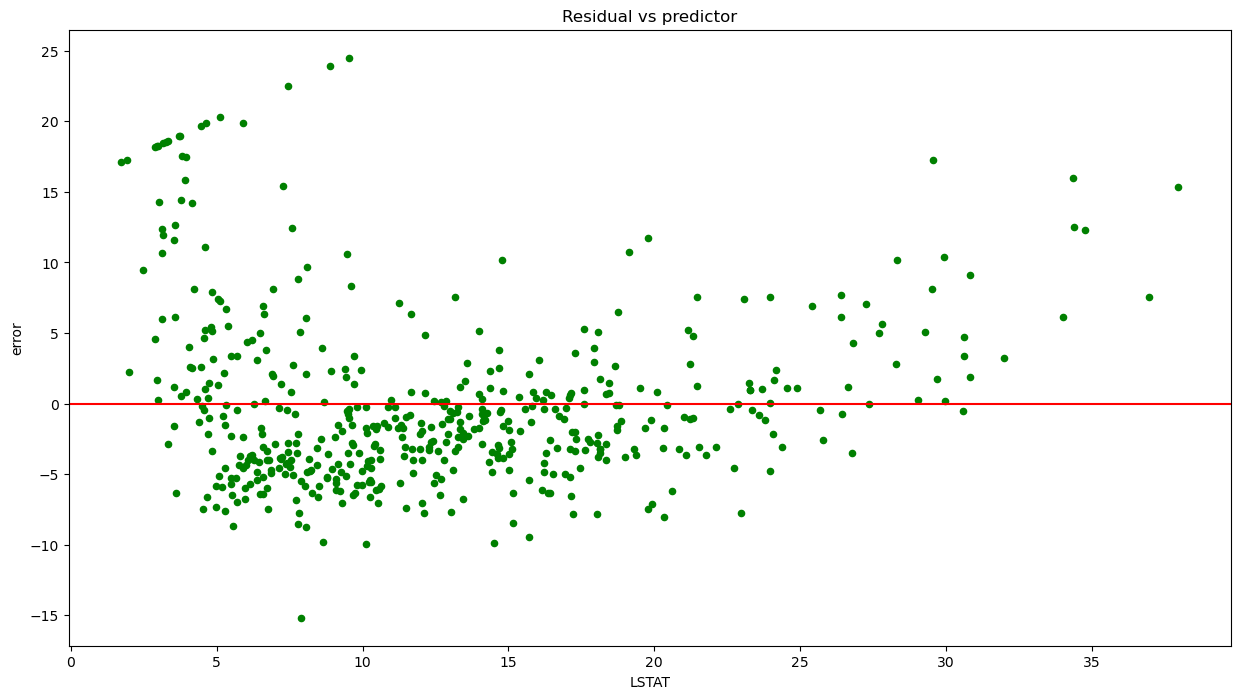

In [17]:
# Equal Variance
# Residual vs predictor scatter plot
# checks whether errors depend on LSTAT

housing.plot(
    kind='scatter',
    x='LSTAT',
    y='error',
    figsize=(15, 8),
    color='green'
)

# add reference line at zero error
# helps identify bias in predictions
plt.title('Residual vs predictor')
plt.axhline(y=0, color='red')

# show plot
plt.show()

In [20]:
# Load index panel dataset
# index_col='Date' → use Date column as the index

indicepanel = pd.read_csv('data/indice/indicepanel.csv', index_col='Date')

# display first 5 rows
indicepanel.head()

,spy,spy_lag1,sp500,nasdaq,dji,cac40,daxi,aord,hsi,nikkei,Price
Date,,,,,,,,,,,
2008-01-04,-1.529998,-1.570008,-3.540039,-40.879883,2.43945,5.489746,-27.990235,-2.300293,515.349609,-464.320313,143.339996
2008-01-07,0.270004,-1.529998,-29.940064,-56.930176,-245.40918,-111.689941,-102.709961,-27.500000,216.951171,-48.830078,141.809998
2008-01-08,-2.990006,0.270004,1.640015,-7.179931,19.75000,44.509766,33.680176,-33.899902,-354.060547,99.370117,142.080002
2008-01-09,0.589997,-2.990006,-25.459961,-63.119873,-230.69043,-17.109864,-5.270020,-12.900390,768.359375,234.450195,139.089996
2008-01-10,1.100006,0.589997,16.530029,8.270019,142.90039,9.140137,-40.120117,-100.200196,-195.560547,-158.209961,139.679993


In [21]:
# Split dataset into training and testing sets

# Training set: rows from -2000 to -1000 (older data)
Train = indicepanel.iloc[-2000:-1000, :]

# Testing set: last 1000 rows (most recent data)
Test = indicepanel.iloc[-1000:, :]

In [22]:
# Define multiple linear regression formula
# spy is dependent variable, others are predictors (lag + global indices)

formula = 'spy~spy_lag1+sp500+nasdaq+dji+cac40+aord+daxi+nikkei+hsi'

# Fit OLS regression model on training data
lm = smf.ols(formula=formula, data=Train).fit()

In [23]:
# Generate predictions on training set using fitted model
Train['PredictedY'] = lm.predict(Train)

# Generate predictions on test set using same model
Test['PredictedY'] = lm.predict(Test)

In [ ]:
# Profit of Signal-based strategy

In [24]:
# Create trading signal based on prediction
# 1 if predicted return > 0, else -1 (short position)

Train['Order'] = [1 if sig > 0 else -1 for sig in Train['PredictedY']]

# Compute profit from strategy
# Profit = actual return * position taken
Train['Profit'] = Train['spy'] * Train['Order']

# Cumulative profit over time
Train['Wealth'] = Train['Profit'].cumsum()

# Total profit from training period
print('Total profit made in Train: ', Train['Profit'].sum())

Total profit made in Train:  214.34009500000042


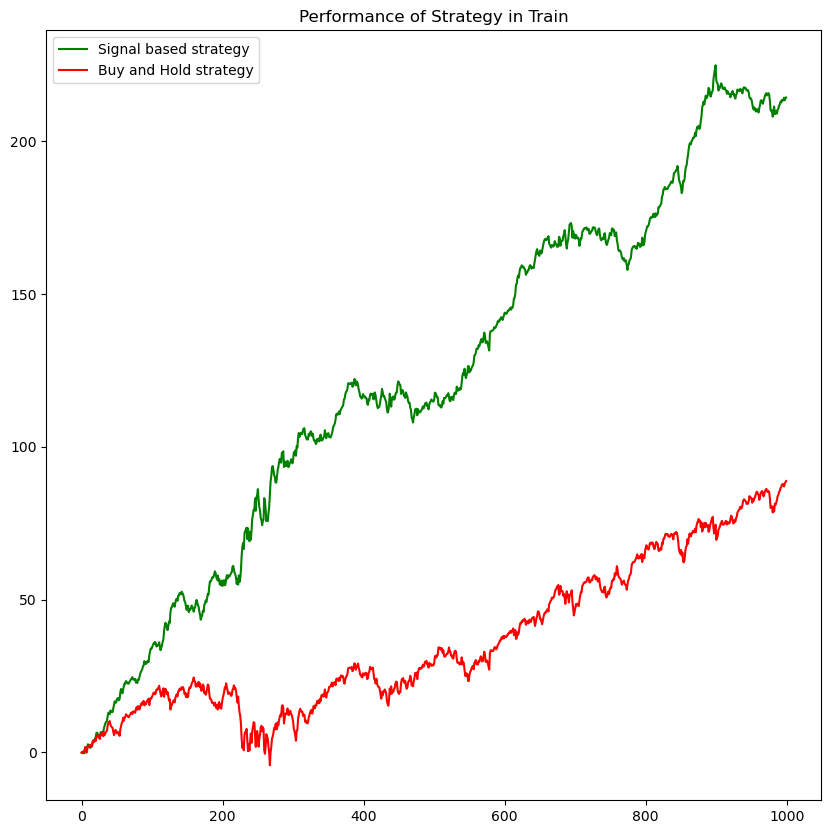

In [25]:
# Plot strategy performance vs buy-and-hold benchmark
# compares cumulative returns of model vs market

plt.figure(figsize=(10, 10))

# title of plot
plt.title('Performance of Strategy in Train')

# signal-based strategy cumulative wealth
plt.plot(
    Train['Wealth'].values,
    color='green',
    label='Signal based strategy'
)

# buy-and-hold strategy cumulative returns
plt.plot(
    Train['spy'].cumsum().values,
    color='red',
    label='Buy and Hold strategy'
)

# legend for clarity
plt.legend()

# display plot
plt.show()

In [26]:
# Generate trading signal for test set
# 1 if predicted return > 0, else -1 (short position)

Test['Order'] = [1 if sig > 0 else -1 for sig in Test['PredictedY']]

# Compute profit from strategy
# Profit = actual return * position taken
Test['Profit'] = Test['spy'] * Test['Order']

# Cumulative wealth over time
Test['Wealth'] = Test['Profit'].cumsum()

# Total profit in test period
print('Total profit made in Test: ', Test['Profit'].sum())



Total profit made in Test:  241.0300879999996


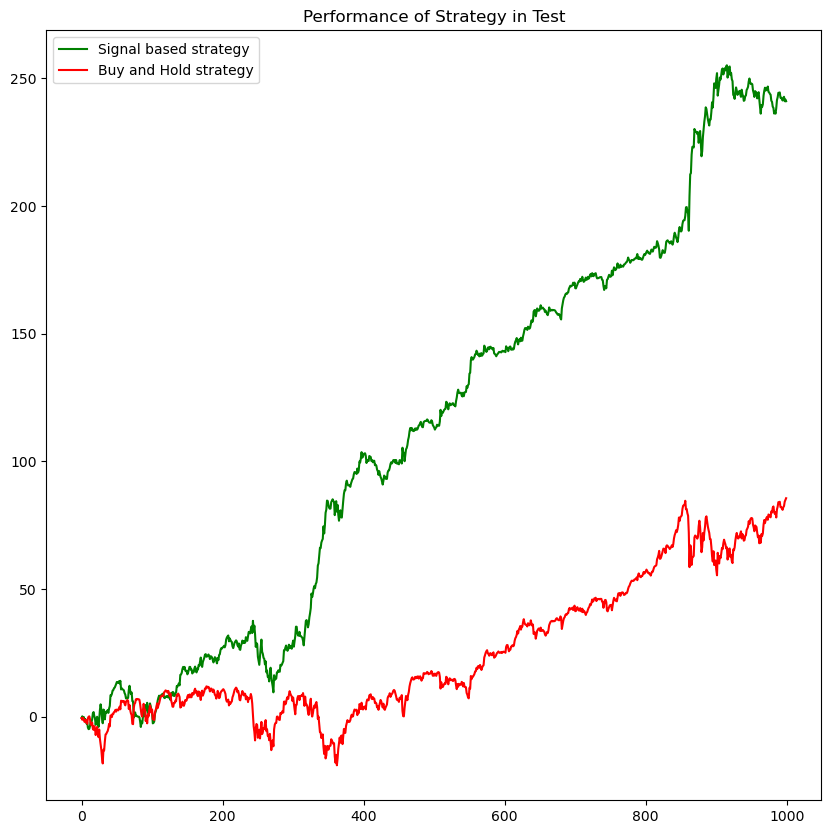

In [27]:
# Plot performance comparison on test set
# compares signal-based strategy vs buy-and-hold

plt.figure(figsize=(10, 10))

# title of chart
plt.title('Performance of Strategy in Test')

# cumulative wealth from trading strategy
plt.plot(
    Test['Wealth'].values,
    color='green',
    label='Signal based strategy'
)

# buy-and-hold benchmark (market return accumulation)
plt.plot(
    Test['spy'].cumsum().values,
    color='red',
    label='Buy and Hold strategy'
)

# show legend
plt.legend()

# display plot
plt.show()

In [ ]:
# Evaluation of model - Practical Standard
# We introduce two common practical standards - **Sharpe Ratio**, **Maximum Drawdown** to evaluate our model performance


In [28]:
# Adjust wealth series to include initial price level
# This shifts cumulative profit so it starts from actual price level

# Add starting price to training wealth
Train['Wealth'] = Train['Wealth'] + Train.loc[Train.index[0], 'Price']

# Add starting price to test wealth
Test['Wealth'] = Test['Wealth'] + Test.loc[Test.index[0], 'Price']

In [29]:
# Compute log returns of strategy wealth
# Return = log(Wt) - log(Wt-1)

Train['Return'] = np.log(Train['Wealth']) - np.log(Train['Wealth'].shift(1))

# remove missing value from first row
dailyr = Train['Return'].dropna()

# daily Sharpe Ratio = mean / std of returns
print('Daily Sharpe Ratio is ', dailyr.mean() / dailyr.std(ddof=1))

# annualized Sharpe Ratio (sqrt of 252 trading days)
print('Yearly Sharpe Ratio is ', (252**0.5) * dailyr.mean() / dailyr.std(ddof=1))

Daily Sharpe Ratio is  0.17965076303258026
Yearly Sharpe Ratio is  2.8518674509632205


In [30]:
# Compute log returns of strategy wealth (test set)
# Return = log(Wt) - log(Wt-1)

Test['Return'] = np.log(Test['Wealth']) - np.log(Test['Wealth'].shift(1))

# remove first NaN value
dailyr = Test['Return'].dropna()

# daily Sharpe Ratio
print('Daily Sharpe Ratio is ', dailyr.mean() / dailyr.std(ddof=1))

# annualized Sharpe Ratio (sqrt of 252 trading days)
print('Yearly Sharpe Ratio is ', (252**0.5) * dailyr.mean() / dailyr.std(ddof=1))

Daily Sharpe Ratio is  0.13035126208575035
Yearly Sharpe Ratio is  2.0692621353737883


In [31]:
# Track highest historical wealth value (running peak)
Train['Peak'] = Train['Wealth'].cummax()

# Compute drawdown (loss from peak in % terms)
Train['Drawdown'] = (Train['Peak'] - Train['Wealth']) / Train['Peak']

# maximum drawdown over training period
print('Maximum Drawdown in Train is ', Train['Drawdown'].max())

Maximum Drawdown in Train is  0.06069016443644383


In [32]:
# Track running maximum wealth (peak value)
Test['Peak'] = Test['Wealth'].cummax()

# Compute drawdown as % drop from peak
Test['Drawdown'] = (Test['Peak'] - Test['Wealth']) / Test['Peak']

# maximum drawdown over test period
print('Maximum Drawdown in Test is ', Test['Drawdown'].max())

Maximum Drawdown in Test is  0.11719899524631659


In [ ]:
# Multiple Linear Regression Model
# Let's mimic the process of building our trading model of SPY, base on the historical data of different stock markets

In [34]:
# import all stock market data into DataFrame
aord = pd.read_csv('data/indice/ALLOrdinary.csv', index_col='Date')
nikkei = pd.read_csv('data/indice/Nikkei225.csv', index_col='Date')
hsi = pd.read_csv('data/indice/HSI.csv', index_col='Date')
daxi = pd.read_csv('data/indice/DAXI.csv', index_col='Date')
cac40 = pd.read_csv('data/indice/CAC40.csv', index_col='Date')
sp500 = pd.read_csv('data/indice/SP500.csv', index_col='Date')
dji = pd.read_csv('data/indice/DJI.csv', index_col='Date')
nasdaq = pd.read_csv('data/indice/nasdaq_composite.csv', index_col='Date')
spy = pd.read_csv('data/indice/SPY.csv', index_col='Date')

In [ ]:
# Display first 5 rows of the NASDAQ dataset
nasdaq.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2008-01-02,2653.909912,2661.500000,2597.810059,2609.629883,2609.629883,2076690000
2008-01-03,2611.959961,2624.270020,2592.179932,2602.679932,2602.679932,1970200000
2008-01-04,2571.080078,2571.080078,2502.679932,2504.649902,2504.649902,2516310000
2008-01-07,2514.149902,2521.620117,2471.229980,2499.459961,2499.459961,2600100000
2008-01-08,2506.969971,2527.419922,2440.510010,2440.510010,2440.510010,2566480000


In [36]:
# Step 1: Data Munging
# Create unified dataset for trading model
# index aligned to SPY timestamps

indicepanel = pd.DataFrame(index=spy.index)

# target variable: next-day SPY price change
indicepanel['spy'] = spy['Open'].shift(-1) - spy['Open']

# lag feature (previous day's SPY movement)
indicepanel['spy_lag1'] = indicepanel['spy'].shift(1)

# major US indices daily changes (Open to Open)
indicepanel['sp500'] = sp500["Open"] - sp500['Open'].shift(1)
indicepanel['nasdaq'] = nasdaq['Open'] - nasdaq['Open'].shift(1)
indicepanel['dji'] = dji['Open'] - dji['Open'].shift(1)

# European indices daily changes (Open to Open)
indicepanel['cac40'] = cac40['Open'] - cac40['Open'].shift(1)
indicepanel['daxi'] = daxi['Open'] - daxi['Open'].shift(1)

# Asian / Australia indices (Close to Open)
indicepanel['aord'] = aord['Close'] - aord['Open']
indicepanel['hsi'] = hsi['Close'] - hsi['Open']
indicepanel['nikkei'] = nikkei['Close'] - nikkei['Open']

# SPY reference price
indicepanel['Price'] = spy['Open']

In [37]:
# Display first rows
indicepanel.head()

,spy,spy_lag1,sp500,nasdaq,dji,cac40,daxi,aord,hsi,nikkei,Price
Date,,,,,,,,,,,
2008-01-02,-1.619995,NaN,NaN,NaN,NaN,NaN,NaN,-50.100097,-71.679688,NaN,146.529999
2008-01-03,-1.570008,-1.619995,-20.419922,-41.949951,-217.70019,-71.779785,-104.450195,-2.300293,-162.750000,NaN,144.910004
2008-01-04,-1.529998,-1.570008,-3.540039,-40.879883,2.43945,5.489746,-27.990235,NaN,515.349609,-464.320313,143.339996
2008-01-07,0.270004,-1.529998,-29.940064,-56.930176,-245.40918,-111.689941,-102.709961,-27.500000,216.951171,-48.830078,141.809998
2008-01-08,-2.990006,0.270004,1.640015,-7.179931,19.75000,44.509766,33.680176,-33.899902,-354.060547,99.370117,142.080002


In [38]:
# Check for missing values in each column of the dataset
# isnull() returns True for NaN, then sum() counts them per column

indicepanel.isnull().sum()

spy           1
spy_lag1      1
sp500         1
nasdaq        1
dji           1
cac40        30
daxi         53
aord        319
hsi         121
nikkei      145
Price         0
dtype: int64

In [39]:
# Forward fill missing values using previous valid observation
# This helps maintain time-series continuity

indicepanel = indicepanel.fillna(method='ffill')

# Drop any remaining NaN values after filling
indicepanel = indicepanel.dropna()

In [40]:
# Check for remaining missing values after forward fill and drop

indicepanel.isnull().sum()

spy         0
spy_lag1    0
sp500       0
nasdaq      0
dji         0
cac40       0
daxi        0
aord        0
hsi         0
nikkei      0
Price       0
dtype: int64

In [41]:
# Define file path to save processed dataset
path_save = 'data/indice/indicepanel.csv'

# Save dataframe to CSV 
indicepanel.to_csv(path_save)

In [42]:
# Print number of rows and columns in the dataset


print(indicepanel.shape)

(2677, 11)


In [ ]:
# Step 2: Data Spliting
# Split dataset into training and testing sets
# Train: older window of data
# Test: most recent observations

Train = indicepanel.iloc[-2000:-1000, :]
Test = indicepanel.iloc[-1000:, :]

# Print shapes to confirm split
print(Train.shape, Test.shape)

(1000, 11) (1000, 11)


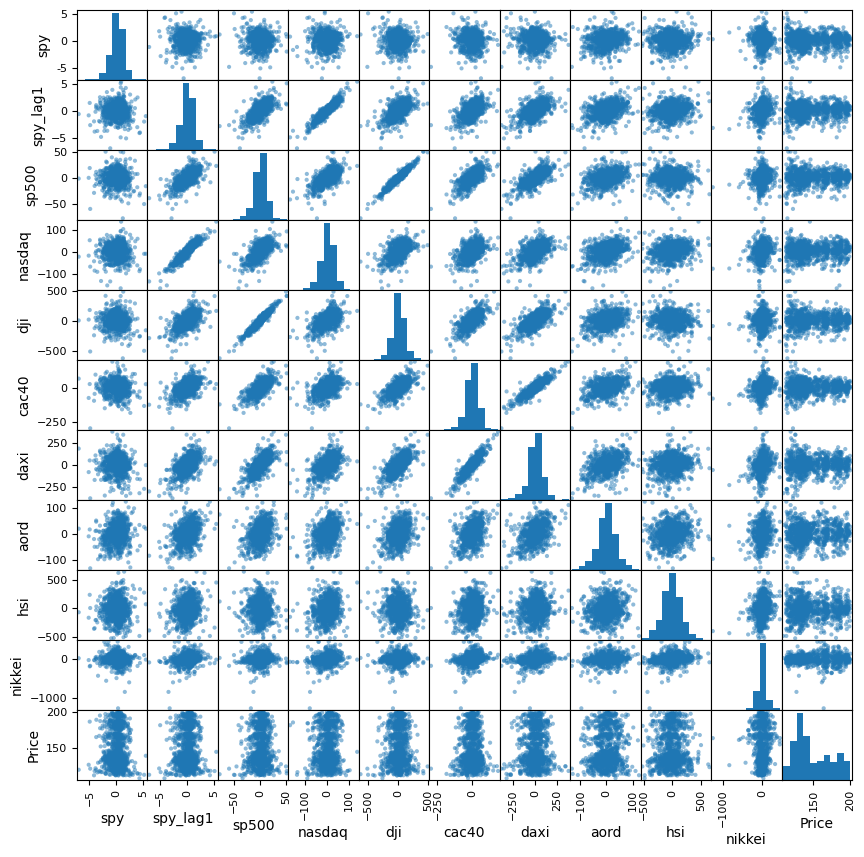

In [44]:
# Step 3: Explore the train data set
# Scatter matrix to visualize relationships between all variables

from pandas.plotting import scatter_matrix

# create pairwise scatter plots for training data
sm = scatter_matrix(Train, figsize=(10, 10))

In [45]:
# Step 4: Check the correlation of each index between spy
# Compute correlation of all features with SPY target
# Excludes last column (usually Price or non-feature column)

corr_array = Train.iloc[:, :-1].corr()['spy']

# print correlation values sorted by feature relationship with spy
print(corr_array)

spy         1.000000
spy_lag1   -0.011623
sp500      -0.018632
nasdaq      0.012333
dji        -0.037097
cac40      -0.055304
daxi       -0.069735
aord        0.179638
hsi         0.031400
nikkei     -0.035048
Name: spy, dtype: float64


In [46]:
# Define multiple linear regression formula
# Predict SPY using lag + global market indices

formula = 'spy~spy_lag1+sp500+nasdaq+dji+cac40+aord+daxi+nikkei+hsi'

# Fit Ordinary Least Squares (OLS) regression model
lm = smf.ols(formula=formula, data=Train).fit()

# Display full statistical summary (R², p-values, coefficients, etc.)
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    spy   R-squared:                       0.067
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     7.962
Date:                Thu, 11 Jun 2026   Prob (F-statistic):           1.97e-11
Time:                        13:33:46   Log-Likelihood:                -1617.7
No. Observations:                1000   AIC:                             3255.
Df Residuals:                     990   BIC:                             3305.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0836      0.039      2.138      0.033       0.007       0.160
spy_lag1      -0.1567      0.091     -1.730      0.084      -0.335       0.021
sp500          0.0221      0.014      1.621      0.105      -0.005       0.049
nasdaq         0.0040      0.004      1.066      0.287      -0.003       0.011
dji           -0.0018      0.001     -1.248      0.212      -0.005       0.001
cac40         -0.0003      0.002     -0.153      0.879      -0.004       0.004
aord           0.0093      0.001      7.492      0.000       0.007       0.012
daxi          -0.0025      0.001     -2.387      0.017      -0.005      -0.000
nikkei        -0.0004      0.000     -1.264      0.207      -0.001       0.000
hsi            0.0003      0.000      1.222      0.222      -0.000       0.001
==============================================================================
Omnibus:                       91.018   Durbin-Watson:                   2.015
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              267.687
Skew:                          -0.450   Prob(JB):                     7.45e-59
Kurtosis:                       5.369   Cond. No.                         405.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [47]:
# Step 5: Make prediction
# Generate model predictions on training data
Train['PredictedY'] = lm.predict(Train)

# Generate model predictions on test data
Test['PredictedY'] = lm.predict(Test)

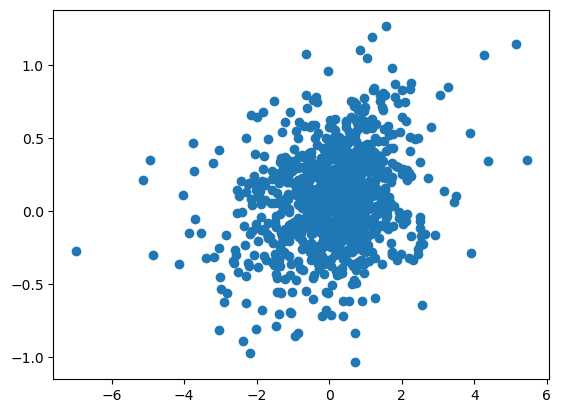

In [48]:
# Scatter plot: actual vs predicted values (training set)

plt.scatter(Train['spy'], Train['PredictedY'])

In [ ]:
# Step 6: Model evaluation - Statistical standard
# We can measure the performance of our model using some statistical metrics - **RMSE**, **Adjusted $R^2$ **

In [49]:
# Function to compute Adjusted R² and RMSE
# model_k = number of predictors in the model
# yname = target variable name

def adjustedMetric(data, model, model_k, yname):
    
    # predicted values from model
    data['yhat'] = model.predict(data)
    
    # Total Sum of Squares (variance in actual data)
    SST = ((data[yname] - data[yname].mean())**2).sum()
    
    # Regression Sum of Squares (explained variance)
    SSR = ((data['yhat'] - data[yname].mean())**2).sum()
    
    # Error Sum of Squares (unexplained variance)
    SSE = ((data[yname] - data['yhat'])**2).sum()
    
    # R-squared
    r2 = SSR / SST
    
    # Adjusted R-squared (penalizes extra predictors)
    adjustR2 = 1 - (1 - r2) * (data.shape[0] - 1) / (data.shape[0] - model_k - 1)
    
    # Root Mean Squared Error
    RMSE = (SSE / (data.shape[0] - model_k - 1)) ** 0.5
    
    return adjustR2, RMSE

In [50]:
# Function to compare model performance on Train vs Test sets
# Uses Adjusted R² and RMSE as evaluation metrics

def assessTable(test, train, model, model_k, yname):
    
    # compute metrics for test set
    r2test, RMSEtest = adjustedMetric(test, model, model_k, yname)
    
    # compute metrics for train set
    r2train, RMSEtrain = adjustedMetric(train, model, model_k, yname)
    
    # create summary table
    assessment = pd.DataFrame(index=['R2', 'RMSE'], columns=['Train', 'Test'])
    
    # fill training results
    assessment['Train'] = [r2train, RMSEtrain]
    
    # fill test results
    assessment['Test'] = [r2test, RMSEtest]
    
    return assessment

In [51]:
# Evaluate model performance on both Train and Test sets
# model_k = 9 predictors used in the regression model
# yname = target variable (spy)

assessTable(Test, Train, lm, 9, 'spy')

,Train,Test
R2,0.059020,0.067248
RMSE,1.226068,1.701291


In [ ]:
# Simple Linear Regression Model

In [52]:
# Load housing dataset for analysis
# index_col='Unnamed: 0' removes extra index column from CSV

housing = pd.read_csv('data/housing.csv', index_col='Unnamed: 0')

# display first 5 rows
housing.head()

,LSTAT,INDUS,NOX,RM,MEDV
0,4.98,2.31,0.538,6.575,24.0
1,9.14,7.07,0.469,6.421,21.6
2,4.03,7.07,0.469,7.185,34.7
3,2.94,2.18,0.458,6.998,33.4
4,5.33,2.18,0.458,7.147,36.2


In [ ]:
# Simple linear regression
# $y_i = \beta_0 + \beta_1 * x_i + \epsilon_i $
# We shall base on the association between LSTAT and MEDV and create a simple linear regression model. 
# Let's use python in estimating the values of B0 and B1 (intercept and slope)

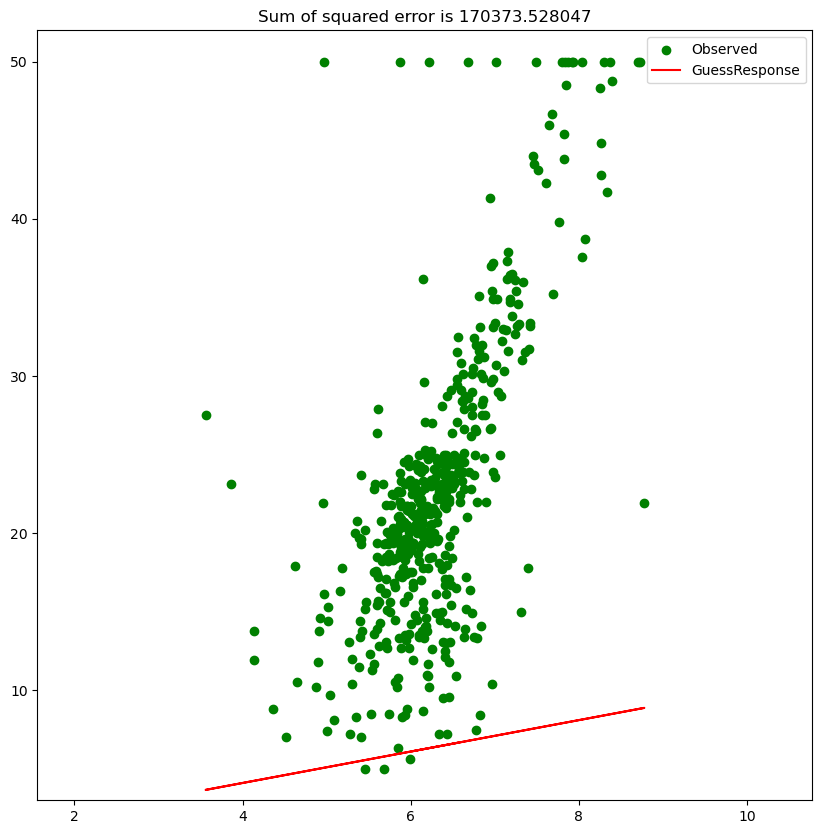

In [53]:
# Manually guess intercept (b0) and slope (b1)
# This creates a simple linear model: MEDV ≈ b0 + b1 * RM

b0 = 0.1
b1 = 1

# predicted values using guessed parameters
housing['GuessResponse'] = b0 + b1 * housing['RM']

# compute prediction errors (residuals)
# error = actual value - predicted value
housing['observederror'] = housing['MEDV'] - housing['GuessResponse']


# plot observed data vs guessed regression line
plt.figure(figsize=(10, 10))

# show total squared error in title
plt.title('Sum of squared error is {}'.format((((housing['observederror'])**2)).sum()))

# scatter plot of real data points
plt.scatter(housing['RM'], housing['MEDV'], color='g', label='Observed')

# guessed regression line
plt.plot(housing['RM'], housing['GuessResponse'], color='red', label='GuessResponse')

# legend for clarity
plt.legend()

# extend axis range slightly for better view
plt.xlim(housing['RM'].min()-2, housing['RM'].max()+2)
plt.ylim(housing['MEDV'].min()-2, housing['MEDV'].max()+2)

# show plot
plt.show()

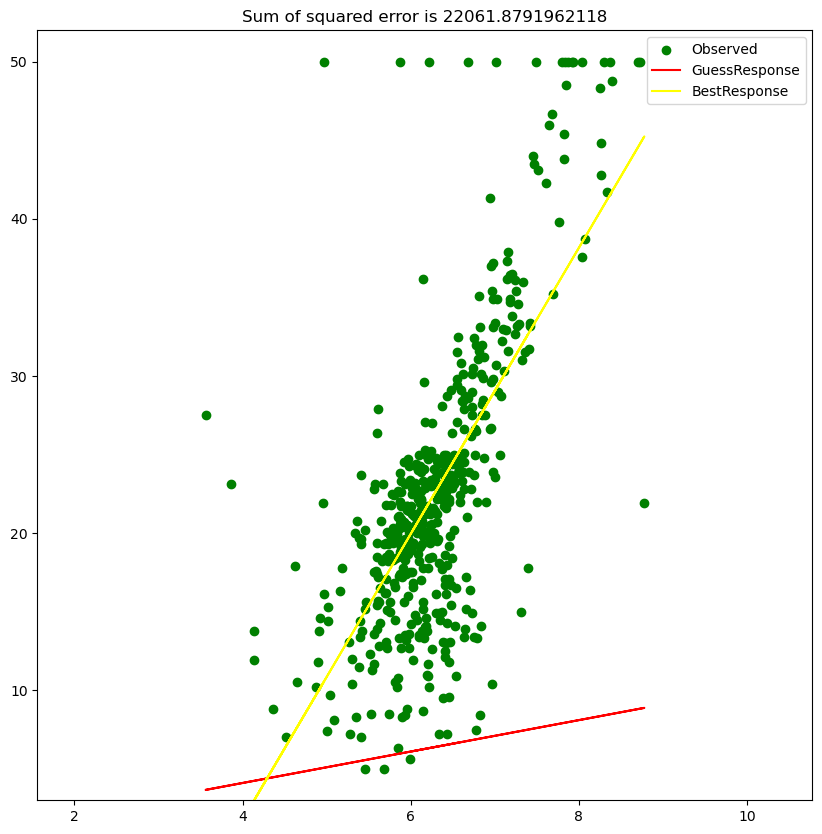

In [54]:
# Least square estimates
# Fit linear regression model: MEDV ~ RM
# RM = average number of rooms per dwelling

formula = 'MEDV~RM'
model = smf.ols(formula=formula, data=housing).fit()

# extract intercept (b0) and slope (b1)
# params[0], params[1] are positional values
b0_ols = model.params[0]
b1_ols = model.params[1]

# compute best-fit regression line
housing['BestResponse'] = b0_ols + b1_ols * housing['RM']

# compute residuals (errors)
housing['error'] = housing['MEDV'] - housing['BestResponse']


# plot comparison of guessed vs best-fit line
plt.figure(figsize=(10, 10))

# show total squared error of best-fit model
plt.title('Sum of squared error is {}'.format((((housing['error'])**2)).sum()))

# observed data points
plt.scatter(housing['RM'], housing['MEDV'], color='g', label='Observed')

# manually guessed line
plt.plot(housing['RM'], housing['GuessResponse'], color='red', label='GuessResponse')

# OLS regression line (best fit)
plt.plot(housing['RM'], housing['BestResponse'], color='yellow', label='BestResponse')

# legend
plt.legend()

# axis limits for better visualization
plt.xlim(housing['RM'].min()-2, housing['RM'].max()+2)
plt.ylim(housing['MEDV'].min()-2, housing['MEDV'].max()+2)

# show plot
plt.show()

In [55]:
# Summary table
# Display full OLS regression results
# includes coefficients, p-values, confidence intervals, and R-squared

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   MEDV   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     471.8
Date:                Thu, 11 Jun 2026   Prob (F-statistic):           2.49e-74
Time:                        13:44:55   Log-Likelihood:                -1673.1
No. Observations:                 506   AIC:                             3350.
Df Residuals:                     504   BIC:                             3359.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -34.6706      2.650    -13.084      0.000     -39.877     -29.465
RM             9.1021      0.419     21.722      0.000       8.279       9.925
==============================================================================
Omnibus:                      102.585   Durbin-Watson:                   0.684
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              612.449
Skew:                           0.726   Prob(JB):                    1.02e-133
Kurtosis:                       8.190   Cond. No.                         58.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""